# Credit Risk Assessment System

## Exploratory Data Analysis (EDA)

### Dataset
Home Credit Default Risk

### Objective
To understand the dataset by analyzing its structure, quality, missing values, distributions, relationships between variables, and key business insights before preprocessing and machine learning.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.chdir('/content/drive/MyDrive')
os.makedirs('credit-risk-assessment-system/data/raw', exist_ok=True)
os.makedirs('credit-risk-assessment-system/data/processed', exist_ok=True)
os.chdir('credit-risk-assessment-system')

print(os.getcwd())
print(os.listdir())

/content/drive/MyDrive/credit-risk-assessment-system
['data']


In [4]:
!ls -la data/raw

total 1429962
-rw------- 1 root root 166133370 Dec 10  2019 application_train.csv
-rw------- 1 root root 170016717 Dec 10  2019 bureau.csv
-rw------- 1 root root     37383 Dec 10  2019 HomeCredit_columns_description.csv
-rw------- 1 root root 723118349 Dec 10  2019 installments_payments.csv
-rw------- 1 root root 404973293 Dec 10  2019 previous_application.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('data/raw/application_train.csv')

print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [11]:
df.describe(include="object").T

,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_TYPE_SUITE,306219,7,Unaccompanied,248526
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186


⬜ Dataset Overview
⬜ Data Types
⬜ Missing Values
⬜ Duplicate Records
⬜ Target Variable Analysis
⬜ Numerical Feature Analysis
⬜ Categorical Feature Analysis
⬜ Outlier Detection
⬜ Correlation Analysis
⬜ Business Insights
⬜ EDA Conclusion

# 3. Data Quality Assessment

## 3.1 Missing Value Analysis

In [12]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
COMMONAREA_MEDI,214865
COMMONAREA_MODE,214865
COMMONAREA_AVG,214865
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_MEDI,213514
...,...
EXT_SOURCE_2,660
AMT_GOODS_PRICE,278
AMT_ANNUITY,12
CNT_FAM_MEMBERS,2


In [13]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values(ascending=False)

,0
COMMONAREA_MEDI,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_AVG,69.872297
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_MEDI,69.432963
...,...
EXT_SOURCE_2,0.214626
AMT_GOODS_PRICE,0.090403
AMT_ANNUITY,0.003902
CNT_FAM_MEMBERS,0.000650


In [14]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df))*100
})

missing_df = missing_df[missing_df["Missing Count"] > 0]

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
).head(20)

,Missing Count,Missing Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


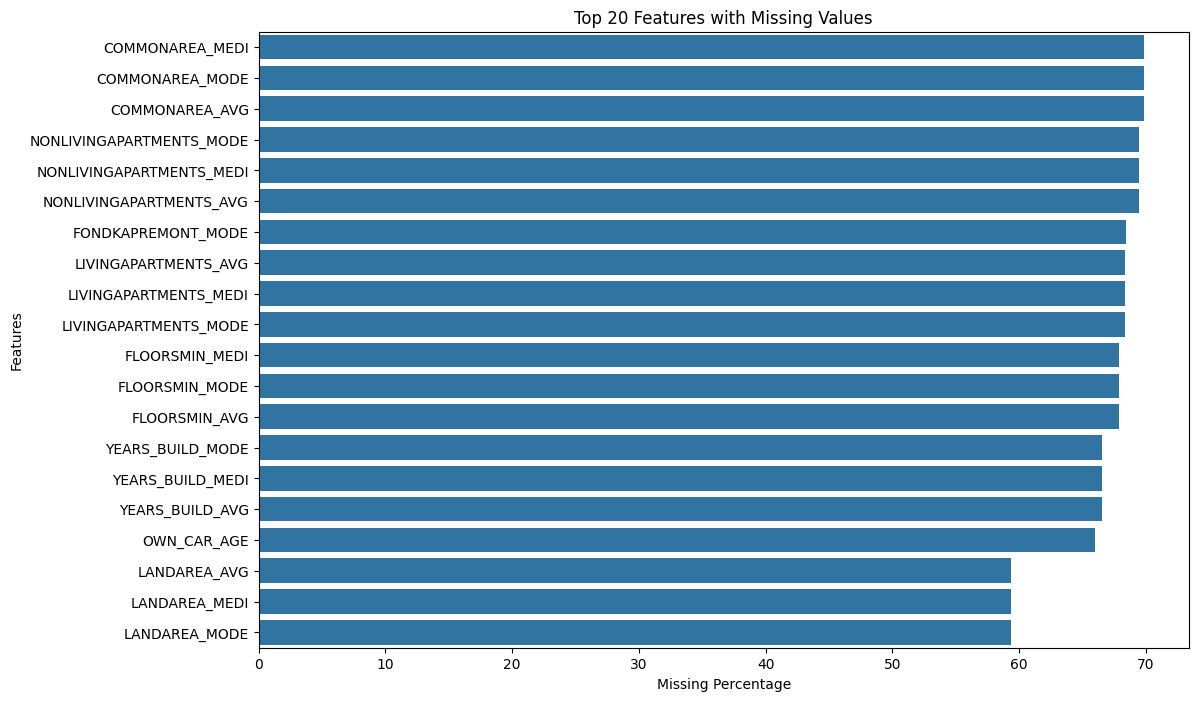

In [15]:
top_missing = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_missing["Missing Percentage"],
    y=top_missing.index
)

plt.title("Top 20 Features with Missing Values")

plt.xlabel("Missing Percentage")

plt.ylabel("Features")

plt.show()

### Observation

The missing value analysis reveals that several housing- and property-related features contain more than 60% missing values. Variables such as `COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, `LIVINGAPARTMENTS_*`, `FLOORSMIN_*`, and `YEARS_BUILD_*` are missing for the majority of applicants.

This suggests that these attributes were either not collected for all customers or were only applicable to certain property types. Such a high percentage of missing values requires careful handling during preprocessing. Features with extremely high missingness may be removed, while others may require appropriate imputation techniques depending on their importance.

Duplicate Analysis

In [16]:
df.duplicated().sum()

np.int64(0)

Target Variable


In [17]:
df["TARGET"].value_counts()

,count
TARGET,
0,282686
1,24825


In [18]:
df["TARGET"].value_counts(normalize=True) * 100

,proportion
TARGET,
0,91.927118
1,8.072882


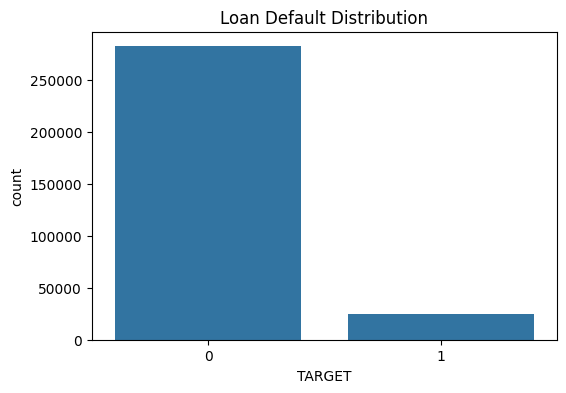

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="TARGET", data=df)

plt.title("Loan Default Distribution")

plt.show()

### Observation

The target variable represents whether a customer defaulted on the loan.

- TARGET = 0 indicates that the client successfully repaid the loan.
- TARGET = 1 indicates that the client experienced payment difficulties or defaulted.

The class distribution is highly imbalanced, with approximately 92% of applicants belonging to the non-default class and only about 8% belonging to the default class.

This imbalance is expected in real-world credit risk datasets because the majority of customers repay their loans.

The imbalance should be considered during model development. Accuracy alone will not be an appropriate evaluation metric. Instead, metrics such as ROC-AUC, Precision, Recall, F1-score, and techniques such as class weighting or SMOTE may be considered.

Numerical Feature Analysis

In [20]:
important_num = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

df[important_num].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0


In [21]:
df["AGE"] = abs(df["DAYS_BIRTH"]) / 365

In [22]:
df["AGE"].describe()

,AGE
count,307511.000000
mean,43.936973
std,11.956133
min,20.517808
25%,34.008219
50%,43.150685
75%,53.923288
max,69.120548


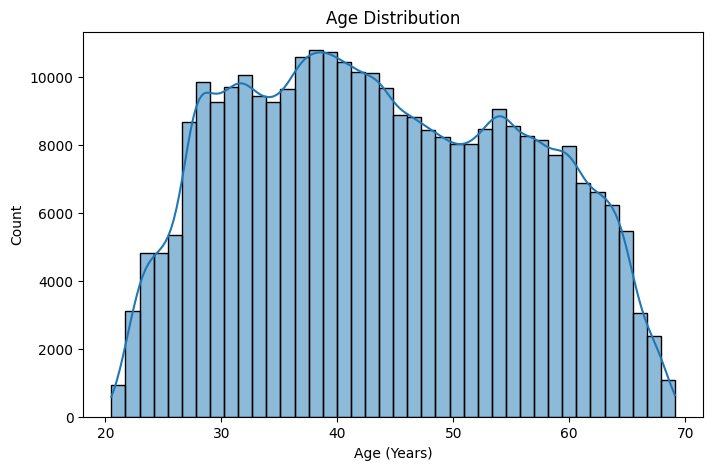

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["AGE"], bins=40, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age (Years)")

plt.show()

### Observation

The age distribution indicates that most loan applicants are between 30 and 60 years of age, representing the economically active population.

Very few applicants are younger than 25 years or older than 65 years, which is expected because financial institutions generally prefer lending to applicants with stable employment and predictable income.

No abnormal or unrealistic age values were observed, indicating good data quality for the AGE feature.

In [25]:
df["AMT_INCOME_TOTAL"].describe()

,AMT_INCOME_TOTAL
count,3.075110e+05
mean,1.687979e+05
std,2.371231e+05
min,2.565000e+04
25%,1.125000e+05
50%,1.471500e+05
75%,2.025000e+05
max,1.170000e+08


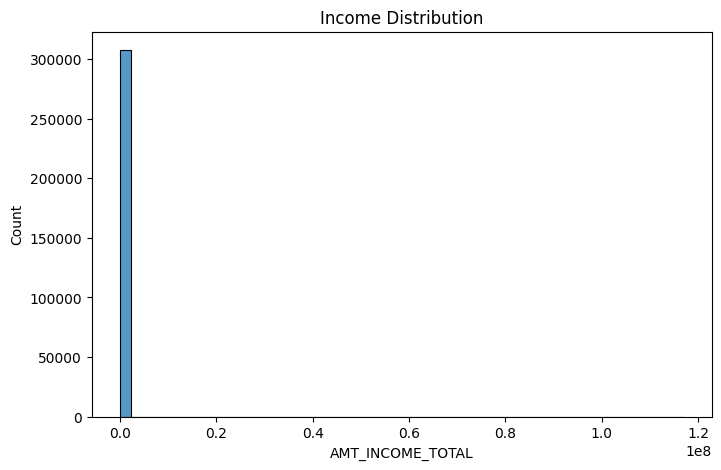

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["AMT_INCOME_TOTAL"], bins=50)

plt.title("Income Distribution")

plt.show()

In [26]:
df["AMT_INCOME_TOTAL"].describe()

,AMT_INCOME_TOTAL
count,3.075110e+05
mean,1.687979e+05
std,2.371231e+05
min,2.565000e+04
25%,1.125000e+05
50%,1.471500e+05
75%,2.025000e+05
max,1.170000e+08


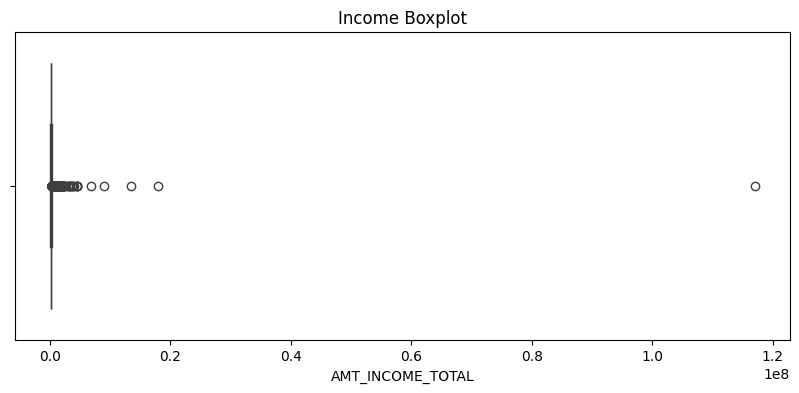

In [27]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["AMT_INCOME_TOTAL"])

plt.title("Income Boxplot")
plt.show()

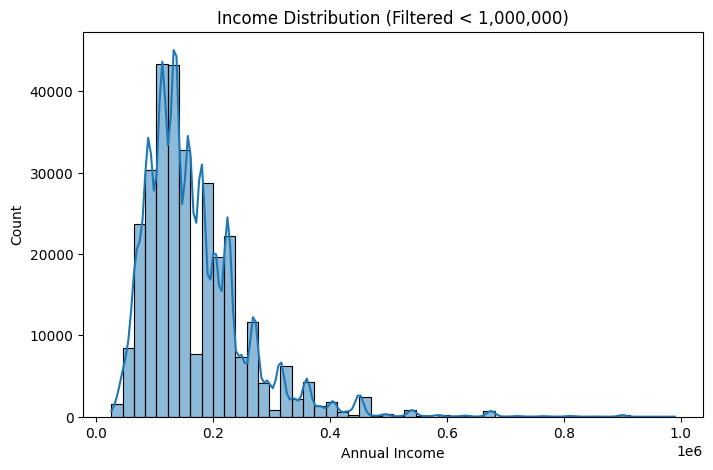

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df[df["AMT_INCOME_TOTAL"] < 1000000]["AMT_INCOME_TOTAL"],
    bins=50,
    kde=True
)

plt.title("Income Distribution (Filtered < 1,000,000)")

plt.xlabel("Annual Income")

plt.show()

### Observation

The annual income distribution is highly right-skewed. Most applicants have relatively low to moderate annual incomes, while a small number of applicants report extremely high incomes. These extreme values compress the histogram, making it difficult to visualize the distribution of the majority of applicants.

Further investigation using summary statistics and boxplots is required to determine whether these values are valid high-income applicants or potential outliers.